## LayoutLMv3 (weak supervision)

Run cells top-to-bottom in a fresh kernel. Paths use `../finalproject_data/` from the project root (next to `scripts/`).


**Imports.** Stdlib, NumPy/Pandas, sklearn split, IPython display, and project helpers for LayoutLMv3, metrics, and dashboards.


In [1]:
"""Shared imports for the LayoutLMv3 weak-supervision pipeline."""
import importlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split

from scripts.eval_utils import normalize_text, summarize_field_prediction_gaps
from scripts.layoutlmv3_model import (
    DEFAULT_FIELDS,
    LayoutLMv3InvoiceDatasetBuilder,
    LayoutLMv3InvoiceTokenClassifier,
)
from scripts.visualize_util import create_analysis_dashboard, visualize_sample_results


**Data.** Load OCR + ground-truth CSVs, merge into `gt_merged_df`, train/test split, and set the weak-label export directory.

Note: combined_results and ground_truth_df are CSVs that can be obtained from the basic_models.ipynb processing cells.

In [2]:
combined_results = pd.read_csv("../finalproject_data/combined_results.csv")

ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")

gt_merged_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
gt_merged_df = gt_merged_df.drop(columns=["File Name", "due_date"], errors="ignore")

train_df, test_df = train_test_split(gt_merged_df, test_size=0.2, random_state=42)

layoutlm_data_dir = "../finalproject_data/layoutlmv3_data"

**Weak labels.** Instantiate `LayoutLMv3InvoiceDatasetBuilder`, build examples from the training split, and save JSONL.


In [3]:
gt_merged_df = gt_merged_df.drop(columns=["File Name", "due_date"], errors="ignore")

layoutlm_data_dir = "../finalproject_data/layoutlmv3_data"

builder = LayoutLMv3InvoiceDatasetBuilder(output_dir=layoutlm_data_dir)

examples = builder.build_examples(
    train_df,
    image_col="processed_path",
    key_col="processed_file",
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    max_examples=None,
)

jsonl_path = builder.save_jsonl(examples)
print(f"Built {len(examples)} weak-labeled examples")
print(f"Saved: {jsonl_path}")

Built 1131 weak-labeled examples
Saved: ../finalproject_data/layoutlmv3_data/layoutlmv3_weak_labels.jsonl


**Weak-label diagnostics.** Coverage for seller/client spans and anchor proximity before you train.


In [4]:
# Weak-label diagnostics for seller/client coverage before training
party_fields = ["seller_name", "client_name"]
rows = []

for ex in examples:
    words = ex.get("words", []) or []
    spans = ex.get("matched_spans", {}) or {}
    norm_words = [normalize_text(w) or "" for w in words]

    for field in party_fields:
        span = spans.get(field)
        matched = isinstance(span, list) and len(span) == 2 and span[0] is not None and span[1] is not None

        span_len = 0
        anchor_nearby = False
        if matched:
            s, e = int(span[0]), int(span[1])
            span_len = max(0, e - s)
            anchor = "seller" if field == "seller_name" else "client"
            left = max(0, s - 12)
            anchor_nearby = any((tok == anchor or tok.rstrip(":") == anchor) for tok in norm_words[left:s])

        rows.append({
            "processed_file": ex.get("processed_file"),
            "field": field,
            "matched": bool(matched),
            "span_len": span_len,
            "anchor_nearby": bool(anchor_nearby),
        })

weak_diag_df = pd.DataFrame(rows)

coverage = (
    weak_diag_df
    .groupby("field", as_index=False)
    .agg(
        total=("matched", "size"),
        matched=("matched", "sum"),
        mean_span_len=("span_len", "mean"),
    )
)
coverage["coverage_pct"] = (coverage["matched"] / coverage["total"] * 100).round(2)
coverage["mean_span_len"] = coverage["mean_span_len"].round(2)

display(coverage)

anchor_view = (
    weak_diag_df[weak_diag_df["matched"]]
    .groupby("field", as_index=False)
    .agg(
        matched_rows=("matched", "size"),
        anchor_nearby_count=("anchor_nearby", "sum"),
    )
)
anchor_view["anchor_nearby_pct_of_matched"] = (
    anchor_view["anchor_nearby_count"] / anchor_view["matched_rows"] * 100
).round(2)

display(anchor_view)

# Optional: inspect unmatched examples for manual triage
display(
    weak_diag_df[~weak_diag_df["matched"]]
    .groupby("field")["processed_file"]
    .head(20)
    .reset_index(drop=True)
)


,field,total,matched,mean_span_len,coverage_pct
0,client_name,1131,1131,2.40,100.00
1,seller_name,1131,1130,2.38,99.91


,field,matched_rows,anchor_nearby_count,anchor_nearby_pct_of_matched
0,client_name,1131,1131,100.0
1,seller_name,1130,1130,100.0


0    processed_batch1-1116.jpg
Name: processed_file, dtype: str

**Training.** Train/validation split on examples, fine-tune `LayoutLMv3InvoiceTokenClassifier`, and write the checkpoint directory.


In [5]:
# Train/val split
train_examples, val_examples = train_test_split(examples, test_size=0.2, random_state=42)

layoutlm_output_dir = "../finalproject_data/layoutlmv3_finetuned_model"

layoutlm_detector = LayoutLMv3InvoiceTokenClassifier()
layoutlm_detector.train(
    train_examples=train_examples,
    eval_examples=val_examples,
    output_dir=layoutlm_output_dir,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
)

print(f"Saved LayoutLMv3 model to: {layoutlm_output_dir}")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.weight | MISSING | 
classifier.dense.bias      | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/opt/anaconda3/envs/dsan6500_stable/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Seqeval F1
50,0.421932,0.146700,0.701132
100,0.098604,0.050523,0.800242
150,0.059417,0.045848,0.819662
200,0.045333,0.031860,0.928775
250,0.031499,0.032284,0.827830
300,0.030611,0.030518,0.941251
350,0.024807,0.023569,0.938938
400,0.027701,0.022665,0.946613
450,0.021485,0.018829,0.949766
500,0.015827,0.019839,0.955823


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/envs/dsan6500_stable/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/envs/dsan6500_stable/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved LayoutLMv3 model to: ../finalproject_data/layoutlmv3_finetuned_model


**Inference & evaluation.** Reload the fine-tuned weights, run the test split, print metrics, then dashboard + sample overlays.


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Runtime: layoutlmv3-name-resolver-2026-04-28-final
Key overlap: 283
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 283              283      281  0.992933   
1    invoice_date                 283              283      283  1.000000   
2     seller_name                 283              265      225  0.795053   
3     client_name                 283              273      253  0.893993   
4             tax                 283              282      281  0.992933   
5       net_worth                 283              282      273  0.964664   
6    total_amount                 283              283      278  0.982332   

   precision    recall        f1  
0   0.992933  0.992933  0.992933  
1   1.000000  1.000000  1.000000  
2   0.849057  0.795053  0.821168  
3   0.926740  0.893993  0.910072  
4   0.996454  0.992933  0.994690  
5   0.968085  0.964664  0.966372  
6   0.982332  0.982332  0.982332  

Overall: {'accuracy': np.float64(0

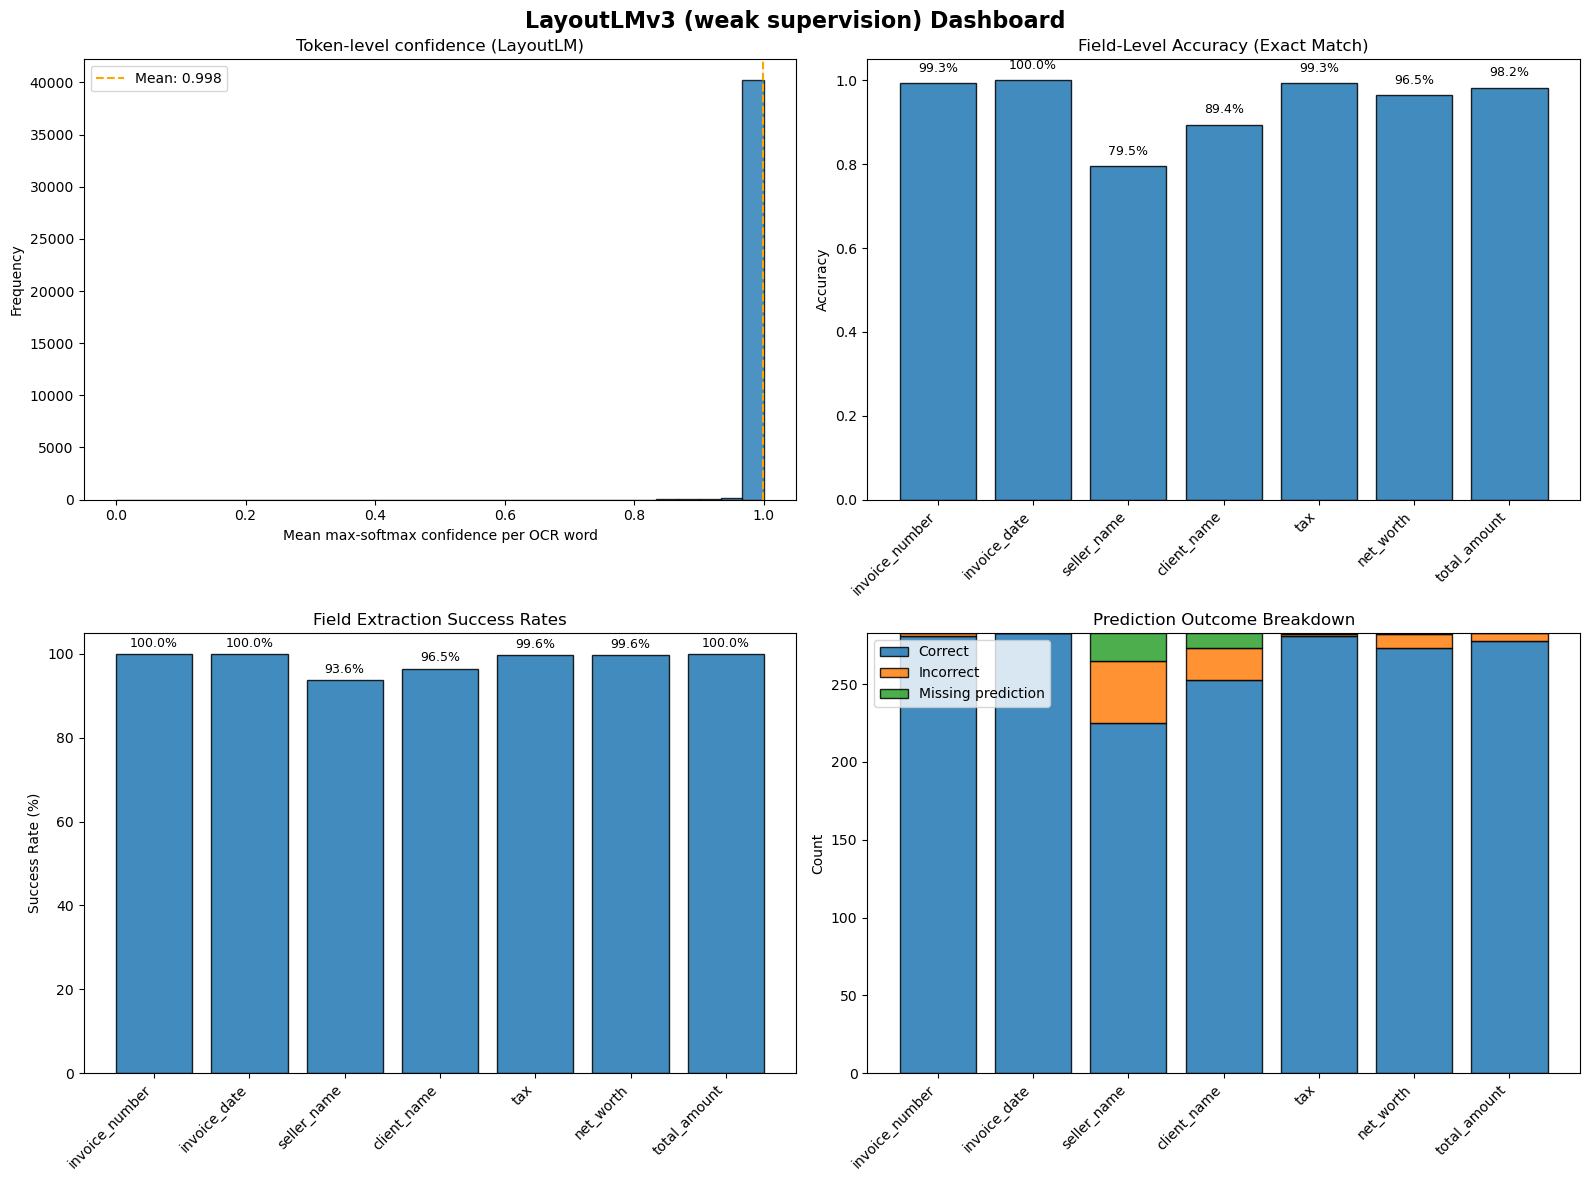

/Users/minhhungtran/Documents/DSAN/DSAN6500/dsan6500-finalproject/scripts/visualize_util.py:363: RuntimeWarning: Mean of empty slice
  "avg_confidence": float(np.nanmean(confidences)),



Sample 1: processed_batch1-0858.jpg
Total words detected: 204
Average confidence: N/A

Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  net_worth: 61563.04
  total_amount: 67719.34
  tax: 6156.30
  client_name: Graham-Martinez
  seller_name: Alexander, Schneider and Russo


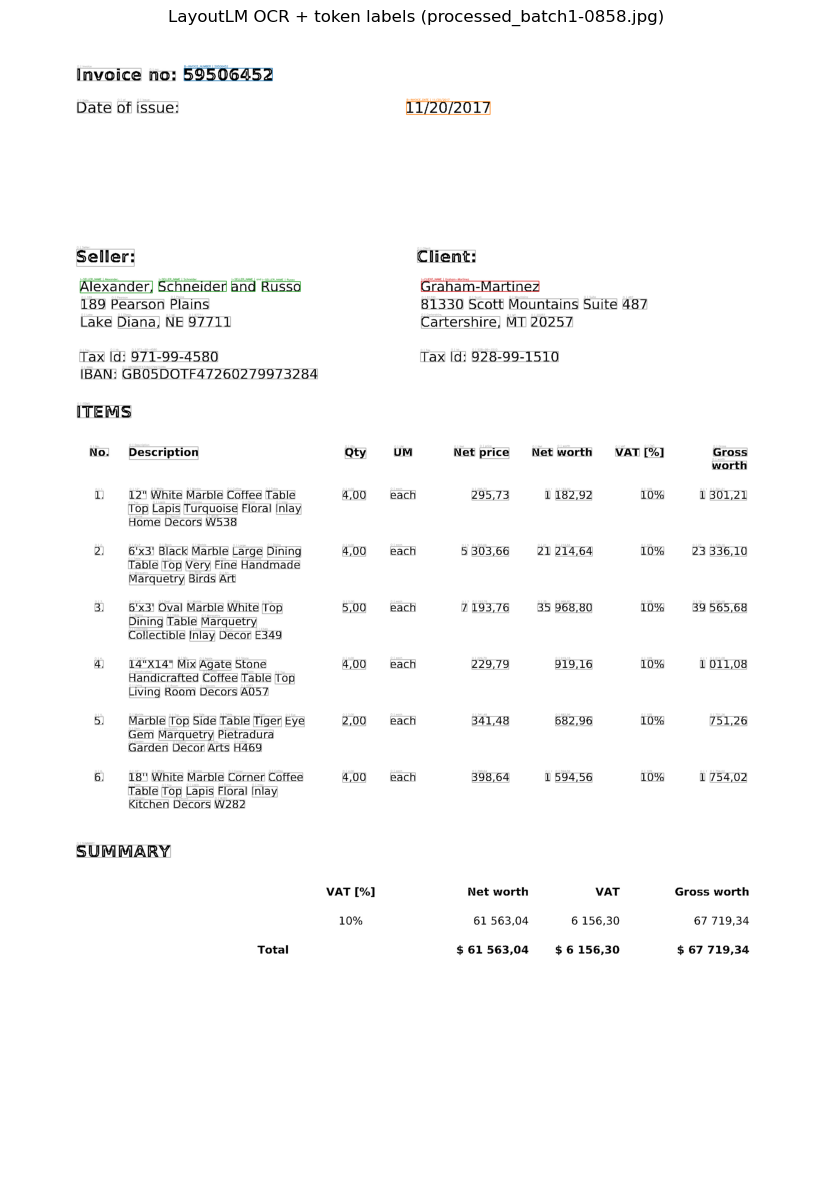


Sample 2: processed_batch1-0935.jpg
Total words detected: 124
Average confidence: N/A

Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  net_worth: 65.42
  total_amount: 71.96
  tax: 6.54
  client_name: Morgan, Farmer and Cook
  seller_name: Johnson, Johnson and Clark


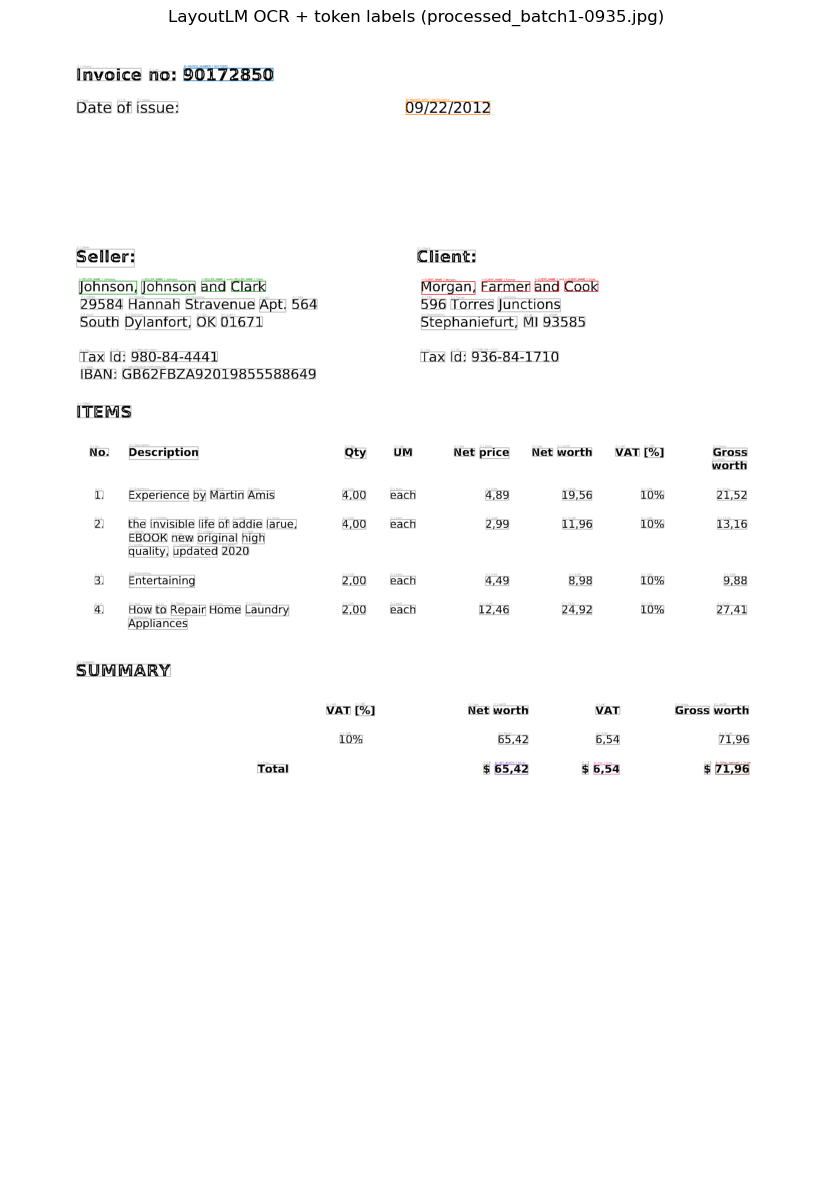

In [6]:
# Inference + evaluation 
import importlib
import scripts.layoutlmv3_model as _layoutlm_mod

importlib.reload(_layoutlm_mod)
from scripts.layoutlmv3_model import LayoutLMv3InvoiceTokenClassifier

layoutlm_output_dir = "../finalproject_data/layoutlmv3_finetuned_model"
layoutlm_detector = LayoutLMv3InvoiceTokenClassifier()
layoutlm_detector.reload_model(layoutlm_output_dir)
layoutlm_detector.enable_seller_anchor_fallback = True
print("Runtime:", layoutlm_detector.runtime_version)  # should show ...-final

layoutlm_pred_df = layoutlm_detector.run_inference(test_df, image_col="processed_path", 
    key_col="processed_file", sample_frac=None, debug_mode=True)

layoutlm_metrics_df, layoutlm_overall = layoutlm_detector.evaluate_against_ground_truth(
    ground_truth_df=test_df,
    pred_df=layoutlm_pred_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    merge_key="processed_file",
)

print(layoutlm_metrics_df)
print("\nOverall:", layoutlm_overall)

_ = create_analysis_dashboard(
    layoutlm_detector.full_results,
    metrics_df=layoutlm_metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"],
    title="LayoutLMv3 (weak supervision) Dashboard",
    panel_model="layoutlm",
)

visualize_sample_results(
    layoutlm_detector.full_results,
    visualize_text_fn=layoutlm_detector.visualize_text_extraction,
    n_samples=2,
    title="LayoutLM sample token-label overlays",
)


**Field gaps.** Mismatch summary for seller and client names on the test split (optional deep dive).


In [7]:
from scripts.eval_utils import summarize_field_prediction_gaps  # if needed list fields

gaps = summarize_field_prediction_gaps(
    ground_truth_df=test_df,
    pred_df=layoutlm_pred_df,
    fields=["seller_name", "client_name"],
    merge_key="processed_file",
)
print(gaps)

         field  gt_nonempty  pred_missing_given_gt  mismatch_given_both  \
0  seller_name          283                     18                   40   
1  client_name          283                     10                   20   

                            sample_keys_missing_pred  
0  [processed_batch1-0412.jpg, processed_batch1-1...  
1  [processed_batch1-0865.jpg, processed_batch1-0...  


### Single-invoice debug

After inference, set `DEBUG_FILE` to a `processed_file` value and inspect GT vs prediction plus `name_resolution` traces.


In [8]:
# Point this at one row in gt_merged_df["processed_file"], then run.
DEBUG_FILE = "processed_batch1-0123.jpg"

import json
from pathlib import Path

from scripts.eval_utils import normalize_text

assert "layoutlm_detector" in globals(), "Run the LayoutLM load + inference cells first."
assert "gt_merged_df" in globals(), "Build gt_merged_df first."

_row = gt_merged_df.loc[gt_merged_df["processed_file"].astype(str) == DEBUG_FILE]
if _row.empty:
    raise ValueError(
        f"No row for processed_file={DEBUG_FILE!r}. "
        f"Try: gt_merged_df['processed_file'].head() to see valid names."
    )

_image_path = _row["processed_path"].iloc[0]
if not Path(str(_image_path)).exists():
    raise FileNotFoundError(_image_path)

_gt = _row.iloc[0]

# Match your batch eval settings
layoutlm_detector.enable_seller_anchor_fallback = True

_pred_fields, _dbg = layoutlm_detector.predict(
    _image_path,
    fields=DEFAULT_FIELDS,
    return_debug=True,
)

print("processed_file:", DEBUG_FILE)
print("image path:", _image_path)
print()

print("--- Ground truth ---")
print("seller_name:", _gt.get("seller_name"))
print("client_name:", _gt.get("client_name"))
print()

print("--- Model output ---")
print("seller_name:", _pred_fields.get("seller_name"))
print("client_name:", _pred_fields.get("client_name"))
print()

print("--- name_resolution (seller / client) ---")
_nr = _dbg.get("name_resolution") or {}
for _k in ("seller_name", "client_name"):
    print(f"\n### {_k}")
    print(json.dumps(_nr.get(_k), indent=2, default=str))

# OCR sanity: do anchor words appear as tokens?
_words, _wl, _yc, _xc, _wconf = layoutlm_detector._predict_word_labels(image_path=_image_path)
_norm = [normalize_text(w) or "" for w in _words]
print("\n--- Per-word LayoutLM confidence (mean max-softmax over subwords) ---")
print(f"  mean={float(np.mean(_wconf)):.4f}, n_words={len(_wconf)}")
print(f"  mean_x_center={float(np.mean(_xc)):.3f} (0=left, 1=right)")
print("\n--- Anchor token hits (word indices; empty means OCR has no that token) ---")
for _term in ("seller", "vendor", "supplier", "client"):
    _idx = LayoutLMv3InvoiceTokenClassifier._anchor_word_positions(_norm, _term)
    print(f"  {_term}: {_idx[:15]}{' ...' if len(_idx) > 15 else ''}")

print("\n--- First 50 OCR words (index: text) ---")
for _i, _w in enumerate(_words[:50]):
    print(f"  {_i:3d}: {_w!r}")


processed_file: processed_batch1-0123.jpg
image path: ../finalproject_data/processed_images/processed_batch1-0123.jpg

--- Ground truth ---
seller_name: Fernandez-Evans
client_name: Ruiz-Cowan

--- Model output ---
seller_name: Fernandez-Evans
client_name: Ruiz-Cowan

--- name_resolution (seller / client) ---

### seller_name
{
  "source": "anchor_fallback",
  "selected": "Fernandez-Evans",
  "top_candidates": [],
  "fallback_trace": {
    "anchors_tried": [
      {
        "anchor": "seller",
        "min_score": 18.0,
        "seller_boundary_stops": true
      }
    ],
    "raw": "Fernandez-Evans Ruiz-Cowan 374 Mora Parks",
    "compact_strict": "Fernandez-Evans",
    "extraction_tier": {
      "min_score": 18.0,
      "seller_boundary_stops": true
    },
    "extraction_anchor": "seller",
    "sanitized_raw": "Fernandez-Evans",
    "compact_org": null
  }
}

### client_name
{
  "source": "anchor_fallback",
  "selected": "Ruiz-Cowan",
  "top_candidates": [],
  "fallback_trace": {
  

**Name weak-label quality.** Table from `matched_spans_meta` for seller/client before training.


In [9]:
# Weak-label name quality diagnostics from matched_spans_meta (before training)
meta_rows = []
for ex in examples:
    pf = ex.get("processed_file")
    meta = ex.get("matched_spans_meta", {}) or {}
    for field in ["seller_name", "client_name"]:
        fm = meta.get(field, {}) or {}
        meta_rows.append({
            "processed_file": pf,
            "field": field,
            "matched": bool(fm.get("matched", False)),
            "quality_ok": bool(fm.get("quality_ok", False)),
        })

name_meta_df = pd.DataFrame(meta_rows)

summary = (
    name_meta_df.groupby("field", as_index=False)
    .agg(
        total=("processed_file", "count"),
        matched=("matched", "sum"),
        quality_ok=("quality_ok", "sum"),
    )
)
summary["matched_pct"] = (summary["matched"] / summary["total"] * 100).round(2)
summary["quality_ok_pct"] = (summary["quality_ok"] / summary["total"] * 100).round(2)
matched_denom = summary["matched"].replace(0, float("nan"))
summary["quality_among_matched_pct"] = ((summary["quality_ok"] / matched_denom) * 100).round(2)

print("Name weak-label quality summary")
display(summary)

print("Sample rows where matched=True but quality_ok=False")
display(
    name_meta_df[(name_meta_df["matched"]) & (~name_meta_df["quality_ok"])].head(30)
)


Name weak-label quality summary


,field,total,matched,quality_ok,matched_pct,quality_ok_pct,quality_among_matched_pct
0,client_name,1131,1131,1131,100.00,100.00,100.0
1,seller_name,1131,1130,1130,99.91,99.91,100.0


Sample rows where matched=True but quality_ok=False


,processed_file,field,matched,quality_ok


### Name-source utilities

Helper functions to summarize seller/client predictions by resolution source; run the next cell to define them.


In [10]:
import pandas as pd
from scripts.eval_utils import normalize_text


def _name_source_debug_df(detector, gt_df, field):
    rows = []
    gt_map = gt_df.set_index("processed_file")[field].to_dict()

    for r in (detector.full_results or []):
        pf = r.get("filename")
        pred = (r.get("invoice_fields") or {}).get(field)
        dbg = (r.get("prediction_debug") or {}).get("name_resolution", {}).get(field, {})
        src = dbg.get("source", "unknown")
        gt = gt_map.get(pf)

        pred_n = normalize_text(pred)
        gt_n = normalize_text(gt)

        if gt_n is None:
            status = "no_gt"
        elif pred_n is None:
            status = "missing"
        elif pred_n == gt_n:
            status = "correct"
        else:
            status = "mismatch"

        rows.append(
            {
                "processed_file": pf,
                "field": field,
                "source": src,
                "status": status,
                "pred": pred,
                "gt": gt,
                "prediction_debug": r.get("prediction_debug") or {},
            }
        )

    return pd.DataFrame(rows)


def show_name_source_summary(detector, gt_df):
    dfs = []
    for f in ("seller_name", "client_name"):
        df = _name_source_debug_df(detector, gt_df, f)
        if len(df):
            dfs.append(df)
    all_df = pd.concat(dfs, ignore_index=True)

    summary = (
        all_df.groupby(["field", "source", "status"], dropna=False)
        .size()
        .rename("rows")
        .reset_index()
        .sort_values(["field", "source", "status"])
    )
    display(summary)
    return all_df


def show_name_source_examples(debug_df, field, source, status="mismatch", n=10):
    q = debug_df[
        (debug_df["field"] == field)
        & (debug_df["source"] == source)
        & (debug_df["status"] == status)
    ].copy()
    if q.empty:
        print("No rows for this filter.")
        return q

    keep = ["processed_file", "field", "source", "status", "pred", "gt"]
    display(q[keep].head(n))

    print("\nDetailed debug traces:")
    for _, row in q.head(n).iterrows():
        nr = ((row["prediction_debug"] or {}).get("name_resolution", {}) or {}).get(field, {})
        print("=" * 100)
        print("processed_file:", row["processed_file"])
        print("source:", nr.get("source"))
        print("pred:", row["pred"])
        print("gt:", row["gt"])
        if "fallback_trace" in nr:
            print("fallback_trace:", nr.get("fallback_trace"))
        if "pair_trace" in nr:
            print("pair_trace:", nr.get("pair_trace"))
        if "top_candidates" in nr:
            print("top_candidates:", nr.get("top_candidates"))

    return q


# Example usage after inference:
# name_debug_df = show_name_source_summary(layoutlm_detector, test_df)
# show_name_source_examples(name_debug_df, field="seller_name", source="anchor_fallback", status="mismatch", n=8)
# show_name_source_examples(name_debug_df, field="client_name", source="pair_fallback", status="mismatch", n=8)


**Run name-source utilities.** Execute summaries and filtered examples (edit sources/status as needed).


In [11]:
# Run this after your inference/eval cell
name_debug_df = show_name_source_summary(layoutlm_detector, test_df)

# Quick drill-downs (edit as needed):
_ = show_name_source_examples(name_debug_df, field="seller_name", source="anchor_fallback", status="mismatch", n=8)
_ = show_name_source_examples(name_debug_df, field="client_name", source="anchor_fallback", status="mismatch", n=8)


,field,source,status,rows
0,client_name,anchor_fallback,correct,158
1,client_name,anchor_fallback,mismatch,20
2,client_name,entity,correct,72
3,client_name,inline_pair_fallback,correct,23
4,client_name,missing,missing,10
5,seller_name,anchor_fallback,correct,83
6,seller_name,anchor_fallback,mismatch,39
7,seller_name,entity,correct,104
8,seller_name,inline_pair_fallback,correct,38
9,seller_name,inline_pair_fallback,mismatch,1


,processed_file,field,source,status,pred,gt
17,processed_batch1-1267.jpg,seller_name,anchor_fallback,mismatch,Cooper Benton,"Farley, Hayes and Cooper"
19,processed_batch1-1446.jpg,seller_name,anchor_fallback,mismatch,Rodriguez-Stevens,"Chapman, Kim and Green"
21,processed_batch1-0979.jpg,seller_name,anchor_fallback,mismatch,Goodman-Rangel,"Terry, Forbes and Franklin"
24,processed_batch1-0355.jpg,seller_name,anchor_fallback,mismatch,Moyer-Jones,"Logan, Deleon and Ayers"
25,processed_batch1-0899.jpg,seller_name,anchor_fallback,mismatch,Alexander Roads,Rios-Ramirez
36,processed_batch1-0473.jpg,seller_name,anchor_fallback,mismatch,Williams-Jimenez,"Rose, Smith and Moreno"
43,processed_batch1-0840.jpg,seller_name,anchor_fallback,mismatch,Cole Groves,"James, Becker and Walters"
56,processed_batch1-1085.jpg,seller_name,anchor_fallback,mismatch,Stewart Daniel,"Rowe, Payne and Stewart"



Detailed debug traces:
processed_file: processed_batch1-1267.jpg
source: anchor_fallback
pred: Cooper Benton
gt: Farley, Hayes and Cooper
fallback_trace: {'anchors_tried': [{'anchor': 'seller', 'min_score': 18.0, 'seller_boundary_stops': True}], 'raw': 'Cooper Benton', 'compact_strict': None, 'extraction_tier': {'min_score': 18.0, 'seller_boundary_stops': True}, 'extraction_anchor': 'seller', 'sanitized_raw': 'Cooper Benton', 'compact_org': None, 'compact_loose': 'Cooper Benton'}
top_candidates: []
processed_file: processed_batch1-1446.jpg
source: anchor_fallback
pred: Rodriguez-Stevens
gt: Chapman, Kim and Green
fallback_trace: {'anchors_tried': [{'anchor': 'seller', 'min_score': 18.0, 'seller_boundary_stops': True}], 'raw': 'Green Rodriguez-Stevens 64731 James Branch', 'compact_strict': 'Rodriguez-Stevens', 'extraction_tier': {'min_score': 18.0, 'seller_boundary_stops': True}, 'extraction_anchor': 'seller', 'sanitized_raw': 'Rodriguez-Stevens', 'compact_org': None}
top_candidates: [

,processed_file,field,source,status,pred,gt
290,processed_batch1-0260.jpg,client_name,anchor_fallback,mismatch,USNS Griffin,Mcclain PLC
291,processed_batch1-1100.jpg,client_name,anchor_fallback,mismatch,"Bautistafurt, FL",Hobbs Group
306,processed_batch1-0192.jpg,client_name,anchor_fallback,mismatch,Scott Garden,Browning Ltd
307,processed_batch1-0355.jpg,client_name,anchor_fallback,mismatch,Reed Greens,Moyer-Jones
324,processed_batch1-0249.jpg,client_name,anchor_fallback,mismatch,Jones Circles,Juarez PLC
332,processed_batch1-1383.jpg,client_name,anchor_fallback,mismatch,Martin Curve,Daniels-Farrell
345,processed_batch1-1226.jpg,client_name,anchor_fallback,mismatch,Davis Extensions,Harrison-Davis
346,processed_batch1-0552.jpg,client_name,anchor_fallback,mismatch,"Wellsside, KY",Hall-Cole



Detailed debug traces:
processed_file: processed_batch1-0260.jpg
source: anchor_fallback
pred: USNS Griffin
gt: Mcclain PLC
fallback_trace: {'raw': 'Mcclain PLC USNS Griffin', 'tiers_tried': [{'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}], 'picked_tier': {'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}, 'compact_strict': None, 'compact_loose': 'USNS Griffin'}
top_candidates: []
processed_file: processed_batch1-1100.jpg
source: anchor_fallback
pred: Bautistafurt, FL
gt: Hobbs Group
fallback_trace: {'raw': 'Darlene Fork Bautistafurt, FL 80497 Lake Kennethmouth,', 'tiers_tried': [{'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}], 'picked_tier': {'min_score': 18.0, 'max_tokens_after_anchor': 22, 'max_span_tokens': 12}, 'compact_strict': None, 'compact_loose': 'Bautistafurt, FL'}
top_candidates: []
processed_file: processed_batch1-0192.jpg
source: anchor_fallback
pred: Scott Garden
gt: Browning Ltd
fallback_trace

## Final Model Notes / Limitations / Future Work

### Final Notes
- **Final LayoutLMv3 configuration** uses weakly supervised token classification with inference-time name-resolution heuristics (entity-first, then guarded fallback).
- **Held-out test performance** is strongest so far for name fields (`seller_name` ~84%, `client_name` ~92% in latest run).
- **Observed source mix** indicates entity predictions are reliable when present, while anchor fallback contributes substantial recall.
- **Reproducibility**: inference cell force-reloads `scripts.layoutlmv3_model` and prints `runtime_version` so notebook runs use the intended code version.

### Current Limitations
- **Residual seller mismatches** are mostly hard edge cases where fallback chooses nearby but wrong party-like strings (e.g., alternate hyphenated names or address-adjacent tokens).
- **OCR dependency** remains high: when OCR token order/segmentation is poor, both entity and fallback quality degrade.
- **Heuristic sensitivity**: fallback behavior can shift with small threshold/token-list changes, so gains on one subset may not transfer uniformly.
- **Weak-label noise** in training still constrains entity-share growth for name fields.

### Future Work
- **Improve weak supervision quality** for seller/client spans (coverage + precision) before adding more inference heuristics.
- **Add confidence-calibrated fallback acceptance** (jointly using model token confidence + heuristic score).
- **Introduce small curated validation set** for heuristic tuning to reduce overfitting to ad-hoc mismatch examples.
- **Consider sequence-level reranker** for seller/client candidates (lightweight classifier) as a replacement for hand-tuned rules.
- **Expand OCR robustness** (alternate OCR engines / consensus OCR) for low-quality documents.